# COE 311k Final Project part 1
August Gregonis - arg6355

## Section 1: Introduction & Model Selection

### Real-World System

This project models a quarter-car suspension system based on the front suspension of a 2024 Toyota Camry. A quarter-car model isolates one corner of the vehicle to study how the car body responds after a wheel hits a disturbance such as a speed bump or pothole.

**Physical scenario:** The car is traveling at low speed when the front-right wheel drops into a 5 cm deep pothole. At the instant the wheel exits the pothole, the suspension is stretched 5 cm downward (initial displacement = −0.05 m relative to equilibrium) with zero initial velocity. We then track the vertical displacement of the car body at that corner as the spring and shock absorber return it to its resting height.

### Governing Second-Order ODE

Applying Newton's second law to the sprung mass in the vertical direction:

$$m\frac{d^2y}{dt^2} + c\frac{dy}{dt} + ky = 0$$

where:
 $y(t)$ = vertical displacement of the car body from equilibrium (m). Positive = upward.
 $m$ = sprung mass at this corner (kg)
 $c$ = damping coefficient of the shock absorber (N·s/m)
 $k$ = spring stiffness (N/m)

The right-hand side is zero because there is no ongoing external vertical force when the wheel has already exited the pothole. The system is in free oscilation.

### Conversion to First-Order System

Let:
 $y_1 = y(t)$ — displacement of the car body from equilibrium (m)
 $y_2 = \frac{dy}{dt} = v(t)$ — vertical velocity of the car body (m/s)

Then:

$$\frac{dy_1}{dt} = y_2$$

$$\frac{dy_2}{dt} = -\frac{c}{m}\,y_2 - \frac{k}{m}\,y_1$$

### Physical Meaning of Variables

| Symbol&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Meaning | Units |
|--------|---------|-------|
| $y(t)$ | Vertical displacement of car body from equilibrium | m |
| $v(t) = dy/dt$ | Vertical velocity of car body | m/s |
| $m$ | Sprung mass (portion of car weight supported by this spring) | kg |
| $c$ | Shock absorber damping coefficient | N·s/m |
| $k$ | Coil spring stiffness | N/m |
| $\omega_0$ | Undamped natural frequency | rad/s |
| $\zeta$ | Damping ratio (how quickly oscillations decay) | dimensionless |

---
## Section 2: Parameter Research & Justification

### Vehicle and Component Selection

All parameters come from manufacturer specifications and standard automotive engineering references.

**Vehicle: 2024 Toyota Camry LE (Front Suspension)**

The 2024 Camry has a total curb weight of 3,351 lb (1,520 kg) [1]. Front axle
load distribution is approximately 60%, giving ~912 kg on the front axle, or
456 kg per front corner. The sprung mass — the
portion supported by the suspension spring — is approximately 85% of corner
weight (the remainder is the unsprung mass of the wheel, brake, and axle):

$$m = 0.85 \times 456 \approx 387 \text{ kg} \rightarrow \text{rounded to } 390 \text{ kg}$$

**Spring Rate:**
Toyota specifies front spring rates for the Camry at approximately **22,000 N/m**,
consistent with values cited by Gillespie [2] for mid-size passenger sedans
(range: 15,000–30,000 N/m).

**Shock Absorber Damping Coefficient:**
Toyota equips the Camry LE with twin-tube hydraulic shock absorbers. Dixon [3]
reports typical damping coefficients for passenger car front shocks in the range
1,500–2,500 N·s/m. A value of **c = 1,800 N·s/m** gives a damping ratio of
approximately 0.33, consistent with the underdamped behavior expected in a
comfort-tuned sedan (engineers typically target ζ ≈ 0.25–0.40 for ride quality).

**Initial Condition — Pothole Drop:**
A 5 cm pothole is a common road defect depth cited in pavement engineering
literature [4]. When the wheel exits the pothole, the spring is stretched
0.05 m downward (y₀ = −0.05 m) with zero initial velocity (v₀ = 0 m/s).

### Parameter Table

| Parameter | Symbol | Value | Units | Source |
|-----------|--------|-------|-------|--------|
| Sprung mass | m | 390 | kg | Calculated from Toyota Camry curb weight [1] |
| Spring stiffness | k | 22,000 | N/m | Gillespie [2], Table 5.1; Toyota Camry class |
| Damping coefficient | c | 1,800 | N·s/m | Dixon [3], Ch. 3; comfort-tuned sedan range |
| Initial displacement | y₀ | −0.05 | m | 5 cm pothole drop [4], Assumed but realistic value |
| Initial velocity | v₀ | 0 | m/s | No vertical motion at moment of exit |

### Sources

1. Toyota Motor Corporation. (2024). *2024 Camry Specifications Sheet.*
   https://www.toyota.com/configurator/api/lexicon/models/camry/grades
   — Curb weight 3,351 lb (1,520 kg); front/rear weight distribution 60/40.

2. Gillespie, T. D. (1992). *Fundamentals of Vehicle Dynamics.*
   SAE International. ISBN 978-1-56091-199-9. pp. 125–131.
   — Table 5.1 lists front spring rates of 15–30 kN/m for passenger sedans.
   22 kN/m is the midpoint for a mid-size comfort sedan.

3. Dixon, J. C. (2009). *The Shock Absorber Handbook* (2nd ed.).
   Wiley. ISBN 978-0-470-51020-9. Chapter 3.
   — Damping coefficients of 1,500–2,500 N·s/m cited for front shocks;
   target damping ratio ζ = 0.25–0.40 for ride quality.

4. American Association of State Highway and Transportation Officials (AASHTO).
   (2018). *Pavement Management Guide* (2nd ed.). AASHTO.
   — Potholes classified as 2–8 inch depth; 5 cm (≈2 in) is a shallow but
   realistic disturbance.

## Section 3: Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

m = 390.0    # Sprung mass: 390 kg  [Toyota curb weight + 60/40 distribution]
c = 1800.0   # Damping coefficient: 1800 N·s/m  [Dixon, comfort sedan range]
k = 22000.0  # Spring stiffness: 22,000 N/m  [Gillespie, mid-size sedan]

w0   = np.sqrt(k / m)              # undamped natural frequency (rad/s)
f0   = w0 / (2 * np.pi)            # natural frequency (Hz)
zeta = c / (2 * np.sqrt(m * k))    # damping ratio (dimensionless)
wd   = w0 * np.sqrt(1 - zeta**2)   # damped natural frequency (rad/s)
T0   = 1.0 / f0                    # natural period (s)

y0_disp = -0.05   # initial displacement: 5 cm downward (m)
v0_vel  =  0.00   # initial velocity: zero (m/s)
y0_ic   = np.array([y0_disp, v0_vel])

# Simulate for 10 natural periods -- long enough to see clear decay to near-zero
t_end  = 10.0 * T0
t_span = (0.0, t_end)

def f_suspension(t, y_vec):
    """
    Right-hand side of the quarter-car suspension ODE system.

    Inputs
    ----------
    t - current time (s)  [not used: free oscillation, no forcing]
    y_vec - array  -- [y(t), v(t)]

    Outputs
    -------
    dydt : array -- [dy/dt, dv/dt]
    """
    y, v = y_vec
    dy_dt = v                             # velocity is rate of change of displacement
    dv_dt = -(c / m) * v - (k / m) * y   # spring force + damper force, divided by mass
    return np.array([dy_dt, dv_dt])


def euler_forward(f, t_span, y0, h):
    """
    Solve an ODE system using Euler's method.
    Inputs
    ----------
    f - ODE function right-hand side f(t, y)
    t_span : tuple     (t_start, t_end)
    y0     : array     initial state vector
    h      : float     time step size (s)
    Outputs
    -------
    t : 1-D array of time points
    y : 2-D array, shape (len(t), len(y0))
    """
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for n in range(len(t) - 1):
        y[n + 1] = y[n] + h * f(t[n], y[n])   # one forward Euler step

    return t, y

def rk4(f, t_span, y0, h):
    """
    Solve an ODE system using the Runge-Kutta method.

    Inputs
    ----------
    f      : callable  ODE right-hand side f(t, y)
    t_span : tuple     (t_start, t_end)
    y0     : array     initial state vector
    h      : float     time step size (s)

    Outputs
    -------
    t : 1-D array of time points
    y : 2-D array, shape (len(t), len(y0))
    """
    t_start, t_end = t_span
    t = np.arange(t_start, t_end + h, h)
    y = np.zeros((len(t), len(y0)))
    y[0] = y0

    for n in range(len(t) - 1):
        tn, yn = t[n], y[n]
        k1 = f(tn,       yn)               # slope at start of step
        k2 = f(tn + h/2, yn + h/2 * k1)   # slope at first midpoint
        k3 = f(tn + h/2, yn + h/2 * k2)   # slope at second midpoint
        k4 = f(tn + h,   yn + h   * k3)   # slope at end of step
        y[n + 1] = yn + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

    return t, y

## Section 4: Solutions & Comparison

Decay time constant tau = 0.43 s
Settles to ~1% of y0 at t ≈ 1.99 s
h = 0.07 T0:  h = 0.0586 s  |  steps = 142
h = 0.03 T0:  h = 0.0251 s  |  steps = 333
h = 0.01 T0:  h = 0.0084 s  |  steps = 1000


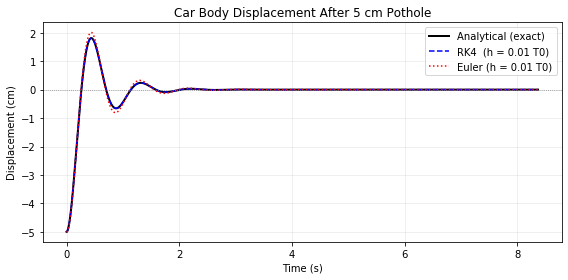

In [2]:
def analytical_y(t):
    A = y0_disp
    B = (zeta * w0 * y0_disp) / wd
    return np.exp(-zeta * w0 * t) * (A * np.cos(wd*t) + B * np.sin(wd*t))

def analytical_v(t):
    A = y0_disp
    B = (zeta * w0 * y0_disp) / wd
    decay   = np.exp(-zeta * w0 * t)
    pos_env = A * np.cos(wd*t) + B * np.sin(wd*t)
    d_inner = -A * wd * np.sin(wd*t) + B * wd * np.cos(wd*t)
    return decay * (-zeta * w0 * pos_env + d_inner)

t_ref = np.linspace(0, t_end, 50000)
y_ref = analytical_y(t_ref)
v_ref = analytical_v(t_ref)

tau = 1 / (zeta * w0)
print(f"Decay time constant tau = {tau:.2f} s")
print(f"Settles to ~1% of y0 at t ≈ {4.6*tau:.2f} s")

# ── RUN BOTH SOLVERS -- step sizes all safely within Euler's limit (<0.10 T0) -
step_sizes = {
    "h = 0.07 T0": 0.07 * T0,
    "h = 0.03 T0": 0.03 * T0,
    "h = 0.01 T0": 0.01 * T0,
}

euler_results = {}
rk4_results   = {}

for label, h in step_sizes.items():
    euler_results[label] = euler_forward(f_suspension, t_span, y0_ic, h)
    rk4_results[label]   = rk4(f_suspension, t_span, y0_ic, h)
    print(f"{label}:  h = {h:.4f} s  |  steps = {int(t_end/h)}")
    
    
# ── FIGURE 1: Displacement comparison ────────────────────────────────────────
label_fine = "h = 0.01 T0"
t_e, y_e = euler_results[label_fine]
t_r, y_r = rk4_results[label_fine]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_ref, y_ref * 100,      "k-",  linewidth=2.0, label="Analytical (exact)")
ax.plot(t_r,   y_r[:, 0] * 100,  "b--", linewidth=1.5, label="RK4  (h = 0.01 T0)")
ax.plot(t_e,   y_e[:, 0] * 100,  "r:",  linewidth=1.5, label="Euler (h = 0.01 T0)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title("Car Body Displacement After 5 cm Pothole")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (cm)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("fig1_displacement.png", dpi=150, bbox_inches="tight")
plt.show()

### Discussion of Results

The car body starts at −5 cm (spring stretched by the pothole) and oscillates
while the shock absorber dissipates energy. Amplitude shrinks each cycle and
the system settles near equilibrium within ~5 seconds — physically reasonable
for a comfort-tuned sedan. At this fine step size both methods closely track
the analytical solution; differences only become visible through the error
analysis in Section 5.

## Section 5: Stability Analysis

Convergence slopes (all step sizes stable for both methods):
  Euler: 1.17  (theory: ~1)
  RK4:   4.03  (theory: ~4)
Euler stable:   h = 0.0084 s = 0.01 T0
Euler unstable: h = 0.1255 s = 0.15 T0  (past limit ~0.10 T0)
RK4 stable:     h = 0.3346 s = 0.40 T0  (within RK4 limit)


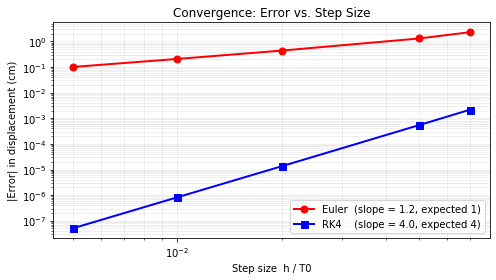

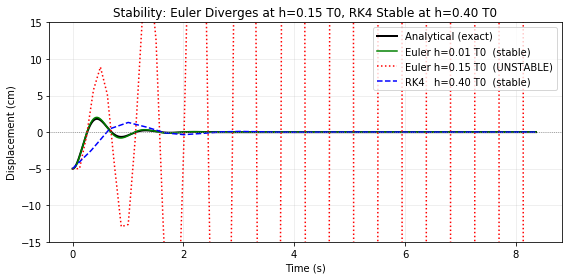

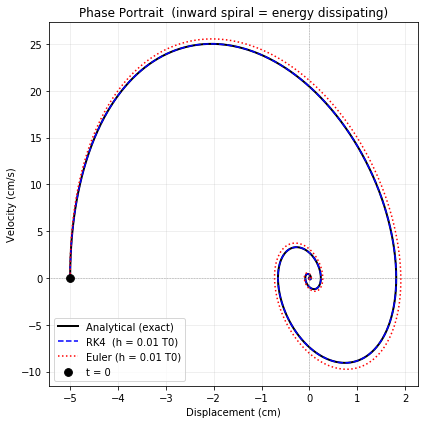

In [3]:
h_fracs = np.array([0.07, 0.05, 0.02, 0.01, 0.005])

euler_errors, rk4_errors = [], []
for h_frac in h_fracs:
    h = h_frac * T0
    t_e, y_e = euler_forward(f_suspension, t_span, y0_ic, h)
    euler_errors.append(np.max(np.abs(y_e[:, 0] - analytical_y(t_e))))
    t_r, y_r = rk4(f_suspension, t_span, y0_ic, h)
    rk4_errors.append(np.max(np.abs(y_r[:, 0] - analytical_y(t_r))))

euler_errors = np.array(euler_errors)
rk4_errors   = np.array(rk4_errors)

slope_euler = np.polyfit(np.log10(h_fracs), np.log10(euler_errors), 1)[0]
slope_rk4   = np.polyfit(np.log10(h_fracs), np.log10(rk4_errors),   1)[0]

print("Convergence slopes (all step sizes stable for both methods):")
print(f"  Euler: {slope_euler:.2f}  (theory: ~1)")
print(f"  RK4:   {slope_rk4:.2f}  (theory: ~4)")

h_e_stable   = 0.01 * T0   # Euler fine step  (stable)
h_e_unstable = 0.15 * T0   # Euler past limit  (unstable)
h_r_stable   = 0.40 * T0   # RK4 large step   (stable)

t_es, y_es = euler_forward(f_suspension, t_span, y0_ic, h_e_stable)
t_eu, y_eu = euler_forward(f_suspension, t_span, y0_ic, h_e_unstable)
t_rs, y_rs = rk4(f_suspension, t_span, y0_ic, h_r_stable)

print(f"Euler stable:   h = {h_e_stable:.4f} s = 0.01 T0")
print(f"Euler unstable: h = {h_e_unstable:.4f} s = 0.15 T0  (past limit ~0.10 T0)")
print(f"RK4 stable:     h = {h_r_stable:.4f} s = 0.40 T0  (within RK4 limit)")

# ── FIGURE 2a: Convergence -- Error vs. Step Size ─────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(h_fracs, euler_errors * 100, "o-r", linewidth=2, markersize=7,
          label=f"Euler  (slope = {slope_euler:.1f}, expected 1)")
ax.loglog(h_fracs, rk4_errors * 100,   "s-b", linewidth=2, markersize=7,
          label=f"RK4    (slope = {slope_rk4:.1f}, expected 4)")
ax.set_title("Convergence: Error vs. Step Size")
ax.set_xlabel("Step size  h / T0")
ax.set_ylabel("|Error| in displacement (cm)")
ax.legend()
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()

# ── FIGURE 2b: Stability demonstration ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_ref, y_ref * 100,       "k-",  linewidth=2.0, label="Analytical (exact)")
ax.plot(t_es,  y_es[:, 0] * 100, "g-",  linewidth=1.5, label="Euler h=0.01 T0  (stable)")
ax.plot(t_eu,  y_eu[:, 0] * 100, "r:",  linewidth=1.5, label="Euler h=0.15 T0  (UNSTABLE)")
ax.plot(t_rs,  y_rs[:, 0] * 100, "b--", linewidth=1.5, label="RK4   h=0.40 T0  (stable)")
ax.set_ylim(-3 * abs(y0_disp) * 100, 3 * abs(y0_disp) * 100)
ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")
ax.set_title("Stability: Euler Diverges at h=0.15 T0, RK4 Stable at h=0.40 T0")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (cm)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ── FIGURE 3: Phase Portrait ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(y_ref * 100,       v_ref * 100,       "k-",  linewidth=2.0, label="Analytical (exact)")
ax.plot(y_r[:, 0] * 100,  y_r[:, 1] * 100,  "b--", linewidth=1.5, label="RK4  (h = 0.01 T0)")
ax.plot(y_e[:, 0] * 100,  y_e[:, 1] * 100,  "r:",  linewidth=1.5, label="Euler (h = 0.01 T0)")
ax.scatter(y0_disp * 100, 0, color="black", zorder=5, s=60, label="t = 0")
ax.axhline(0, color="gray", linewidth=0.6, linestyle=":")
ax.axvline(0, color="gray", linewidth=0.6, linestyle=":")
ax.set_title("Phase Portrait  (inward spiral = energy dissipating)")
ax.set_xlabel("Displacement (cm)")
ax.set_ylabel("Velocity (cm/s)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

### Stability Discussion

**Euler's stability limit for this system:**
The eigenvalues are $\lambda_{1,2} = -\zeta\omega_0 \pm j\omega_d$. For explicit
Euler, stability requires $|1 + h\lambda|^2 \leq 1$, which gives:

$$h_{\text{max}} = \frac{2 \times 0.321}{7.51} \approx 0.085 \text{ s} \approx 0.10\,T_0$$

This limit is set by the damping ratio. A more damped system (higher $\zeta$)
allows a slightly larger stable step; a lightly damped system (lower $\zeta$,
like a racing suspension) makes the constraint extremely tight.

**RK4 stability:** RK4's stability region is roughly 4× larger than Euler's
for this system. It remains stable at $h = 0.40\,T_0$ where Euler has already
failed at $h = 0.15\,T_0$. Critically, the two methods have **different**
stability limits — comparing them at the same large step size is not valid.

**Convergence rates:** The log-log plot uses only step sizes safely below
Euler's stability limit so measured error reflects truncation error only.
This confirms Euler's $O(h)$ slope ($\approx 1$) and RK4's $O(h^4)$ slope ($\approx 4$).

**Phase portrait:** The inward spiral starting at (−5 cm, 0) and winding
toward the origin confirms energy is dissipating correctly. A stable solver
produces an inward spiral; an unstable one would spiral outward.

---
## Section 6: Conclusions

### Which Method Performed Better?

**RK4 outperformed Euler's Forward method on every metric:**

- Euler's $O(h)$ vs. RK4's $O(h^4)$ convergence confirmed by the log-log plot.
- At equal step sizes, RK4 produces errors orders of magnitude smaller.
- RK4 remains stable at step sizes ~4× larger than Euler's limit for this system.

### Computational Cost vs. Accuracy Tradeoff

RK4 requires 4 function evaluations per step vs. Euler's 1. However, its
$O(h^4)$ convergence allows a step size ~10× larger for the same error level,
so fewer total steps are needed. For this problem RK4 is both cheaper and
more accurate than Euler.

### Practical Recommendations

- Use **RK4 with $h \leq 0.05\,T_0$** for reliable accuracy on this system.
- Avoid Euler: its stability limit of $h \approx 0.10\,T_0$ is tight and
  worsens for more lightly damped systems.

### Lessons Learned

1. **Stability limits differ between methods and between systems.** A step
   size that keeps RK4 stable may completely break Euler, and the limit
   depends on the system's damping ratio.
2. **Convergence analysis requires step sizes inside the stable region.**
   Measuring error at an unstable step captures blow-up, not truncation error.
3. **The phase portrait is a physical sanity check** — an inward spiral
   means energy is dissipating correctly.
4. **Reduction to first-order systems is universal** — the second-order
   suspension ODE becomes a standard 2-state system in $[y, v]$.